In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Look beside the notebook first, then use the folder supplied for this project.
DATA_PATH = Path("results.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path(r"D:\Fifa Project\Ball data\results.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("Could not find results.csv beside the notebook or in the project folder.")

results = pd.read_csv(DATA_PATH, parse_dates=["date"])

print(f"Loaded: {DATA_PATH.resolve()}")
print(f"Shape: {results.shape}")
print(f"Columns: {results.columns.tolist()}")
display(results.head())
results.info()
print("\nMissing values by column:")
display(results.isna().sum().to_frame("missing_values"))

world_cup_labels = results.loc[
    results["tournament"].str.contains("world cup", case=False, na=False), "tournament"
].value_counts()
print("\nTournament labels containing 'World Cup':")
display(world_cup_labels)

Loaded: D:\Fifa Project\Ball data\results.csv
Shape: (49547, 9)
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49547 entries, 0 to 49546
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49547 non-null  datetime64[ns]
 1   home_team   49547 non-null  object        
 2   away_team   49547 non-null  object        
 3   home_score  49547 non-null  int64         
 4   away_score  49547 non-null  int64         
 5   tournament  49547 non-null  object        
 6   city        49547 non-null  object        
 7   country     49547 non-null  object        
 8   neutral     49547 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 3.1+ MB

Missing values by column:


,missing_values
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0



Tournament labels containing 'World Cup':


tournament
FIFA World Cup qualification      8771
FIFA World Cup                    1068
Viva World Cup                      60
CONIFA World Cup qualification       1
Name: count, dtype: int64

In [24]:
world_cup = results.loc[results["tournament"] == "FIFA World Cup"].copy()

world_cup["result"] = np.select(
    [
        world_cup["home_score"] > world_cup["away_score"],
        world_cup["home_score"] < world_cup["away_score"],
    ],
    ["home_win", "away_win"],
    default="draw",
)
world_cup["goal_difference"] = world_cup["home_score"] - world_cup["away_score"]
world_cup["total_goals"] = world_cup["home_score"] + world_cup["away_score"]
world_cup["year"] = world_cup["date"].dt.year

print(f"FIFA World Cup matches: {len(world_cup)}")
print("\nMatch result counts:")
display(world_cup["result"].value_counts())
display(world_cup[["date", "home_team", "away_team", "home_score", "away_score", "result", "goal_difference", "total_goals"]].head())

FIFA World Cup matches: 1068

Match result counts:


result
home_win    488
away_win    342
draw        238
Name: count, dtype: int64

,date,home_team,away_team,home_score,away_score,result,goal_difference,total_goals
1490,1930-07-13,Belgium,United States,0,3,away_win,-3,3
1491,1930-07-13,France,Mexico,4,1,home_win,3,5
1492,1930-07-14,Brazil,Yugoslavia,1,2,away_win,-1,3
1493,1930-07-14,Peru,Romania,1,3,away_win,-2,4
1494,1930-07-15,Argentina,France,1,0,home_win,1,1


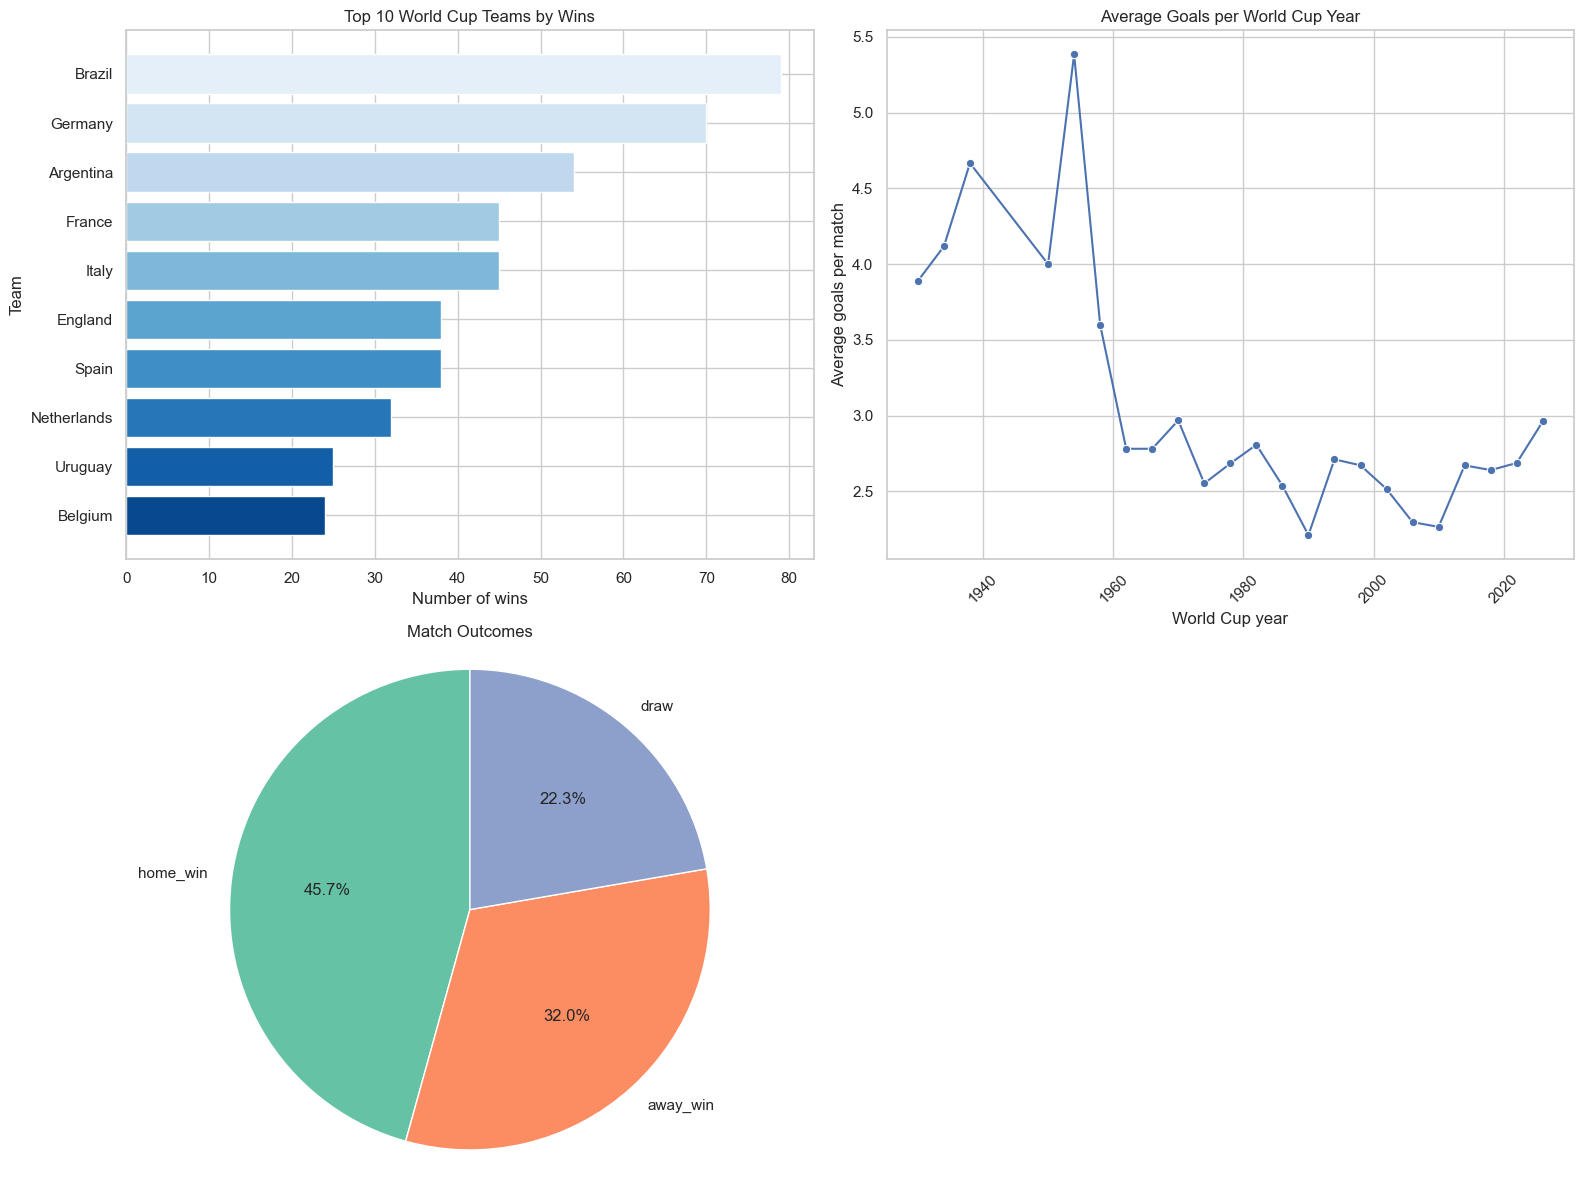

In [25]:
home_wins = world_cup.loc[world_cup["result"] == "home_win", "home_team"].value_counts()
away_wins = world_cup.loc[world_cup["result"] == "away_win", "away_team"].value_counts()
team_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)
top_10_wins = team_wins.head(10).sort_values(ascending=True)

yearly_goals = (
    world_cup.groupby("year", as_index=False)["total_goals"]
    .mean()
    .rename(columns={"total_goals": "average_total_goals"})
)
result_counts = world_cup["result"].value_counts().reindex(
    ["home_win", "away_win", "draw"], fill_value=0
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].barh(top_10_wins.index, top_10_wins.values, color=sns.color_palette("Blues_r", n_colors=10))
axes[0, 0].set_title("Top 10 World Cup Teams by Wins")
axes[0, 0].set_xlabel("Number of wins")
axes[0, 0].set_ylabel("Team")

sns.lineplot(
    data=yearly_goals,
    x="year",
    y="average_total_goals",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Average Goals per World Cup Year")
axes[0, 1].set_xlabel("World Cup year")
axes[0, 1].set_ylabel("Average goals per match")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].pie(
    result_counts.values,
    labels=result_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", n_colors=3),
)
axes[1, 0].set_title("Match Outcomes")
axes[1, 0].axis("equal")

axes[1, 1].axis("off")
fig.tight_layout()
plt.show()

In [26]:
features = world_cup[["home_team", "away_team"]]
target = world_cup["result"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target,
)

team_encoder = ColumnTransformer(
    transformers=[
        ("team_names", OneHotEncoder(handle_unknown="ignore"), ["home_team", "away_team"])
    ]
)

outcome_model = Pipeline(
    steps=[
        ("preprocessor", team_encoder),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)
outcome_model.fit(X_train, y_train)

predictions = outcome_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.3f}")
print("\nClassification report:")
print(
    classification_report(
        y_test,
        predictions,
        labels=["home_win", "away_win", "draw"],
        target_names=["Home win", "Away win", "Draw"],
        zero_division=0,
    )
)


def predict_match(home_team, away_team):
    """Print predicted outcome probabilities for a World Cup matchup."""
    match_features = pd.DataFrame(
        [{"home_team": home_team, "away_team": away_team}]
    )
    probabilities = dict(
        zip(outcome_model.classes_, outcome_model.predict_proba(match_features)[0])
    )

    print(f"{home_team} win probability: {probabilities['home_win']:.1%}")
    print(f"{away_team} win probability: {probabilities['away_win']:.1%}")
    print(f"Draw probability: {probabilities['draw']:.1%}")
    return probabilities


predict_match("Argentina", "France")

Accuracy: 0.439

Classification report:
              precision    recall  f1-score   support

    Home win       0.52      0.62      0.57        98
    Away win       0.40      0.43      0.41        68
        Draw       0.16      0.08      0.11        48

    accuracy                           0.44       214
   macro avg       0.36      0.38      0.36       214
weighted avg       0.40      0.44      0.42       214

Argentina win probability: 65.2%
France win probability: 0.0%
Draw probability: 34.8%


{'away_win': np.float64(0.0),
 'draw': np.float64(0.34797619047619044),
 'home_win': np.float64(0.6520238095238093)}

In [27]:
rankings_path = DATA_PATH.with_name("fifa_rankings.csv")
rankings = pd.read_csv(rankings_path, parse_dates=["rank_date"])

ranking_matches = results.loc[
    results["tournament"] == "FIFA World Cup"
].copy().reset_index(drop=True)
ranking_matches["match_id"] = np.arange(len(ranking_matches))
ranking_matches["result"] = np.select(
    [
        ranking_matches["home_score"] > ranking_matches["away_score"],
        ranking_matches["home_score"] < ranking_matches["away_score"],
    ],
    ["home_win", "away_win"],
    default="draw",
)

rank_data = (
    rankings[["team", "rank_date", "total_points"]]
    .dropna(subset=["team", "rank_date", "total_points"])
    .sort_values("rank_date")
    .drop_duplicates(["team", "rank_date"], keep="last")
)

home_matches = ranking_matches[["match_id", "date", "home_team"]].rename(
    columns={"date": "match_date", "home_team": "team"}
).sort_values("match_date")
home_rankings = pd.merge_asof(
    home_matches,
    rank_data.sort_values("rank_date"),
    left_on="match_date",
    right_on="rank_date",
    by="team",
    direction="backward",
)

away_matches = ranking_matches[["match_id", "date", "away_team"]].rename(
    columns={"date": "match_date", "away_team": "team"}
).sort_values("match_date")
away_rankings = pd.merge_asof(
    away_matches,
    rank_data.sort_values("rank_date"),
    left_on="match_date",
    right_on="rank_date",
    by="team",
    direction="backward",
)

ranking_matches = ranking_matches.merge(
    home_rankings[["match_id", "total_points"]].rename(
        columns={"total_points": "home_rank_points"}
    ),
    on="match_id",
    how="left",
).merge(
    away_rankings[["match_id", "total_points"]].rename(
        columns={"total_points": "away_rank_points"}
    ),
    on="match_id",
    how="left",
)

before_drop = len(ranking_matches)
ranking_matches = ranking_matches.dropna(
    subset=["home_rank_points", "away_rank_points"]
).copy()
print(f"Rankings loaded: {len(rankings):,} rows")
print(f"World Cup matches before dropping missing rankings: {before_drop:,}")
print(f"World Cup matches with both rankings: {len(ranking_matches):,}")
print(f"Rows dropped for missing rankings: {before_drop - len(ranking_matches):,}")
display(
    ranking_matches[
        ["date", "home_team", "away_team", "home_rank_points", "away_rank_points", "result"]
    ].head()
)

Rankings loaded: 63,899 rows
World Cup matches before dropping missing rankings: 1,068
World Cup matches with both rankings: 604
Rows dropped for missing rankings: 464


,date,home_team,away_team,home_rank_points,away_rank_points,result
464,1994-06-17,Germany,Bolivia,60.0,35.0,home_win
465,1994-06-17,Spain,South Korea,56.0,38.0,draw
466,1994-06-18,Colombia,Romania,51.0,55.0,away_win
467,1994-06-18,Italy,Republic of Ireland,57.0,53.0,away_win
468,1994-06-18,United States,Switzerland,47.0,54.0,draw


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

model_data = ranking_matches.dropna(
    subset=["home_rank_points", "away_rank_points", "neutral", "result"]
).copy()
X = model_data[["home_rank_points", "away_rank_points", "neutral"]].copy()
X["neutral"] = X["neutral"].astype(int)
y = model_data["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=["home_win", "away_win", "draw"],
        target_names=["Home win", "Away win", "Draw"],
        zero_division=0,
    )
)


def predict_match(home_team, away_team):
    """Predict outcome probabilities using each team's latest FIFA ranking."""
    def latest_points(team):
        team_rankings = rankings.loc[
            rankings["team"].eq(team), ["rank_date", "total_points"]
        ].dropna(subset=["rank_date", "total_points"])
        if team_rankings.empty:
            raise ValueError(f"No ranking data found for {team!r}.")
        return team_rankings.sort_values("rank_date").iloc[-1]["total_points"]

    match = pd.DataFrame(
        [{
            "home_rank_points": latest_points(home_team),
            "away_rank_points": latest_points(away_team),
            "neutral": 1,
        }]
    )
    probabilities = dict(zip(model.classes_, model.predict_proba(match)[0]))

    print(f"{home_team} win probability: {probabilities['home_win']:.1%}")
    print(f"{away_team} win probability: {probabilities['away_win']:.1%}")
    print(f"Draw probability: {probabilities['draw']:.1%}")
    return probabilities


predict_match("Brazil", "Argentina")

Accuracy: 0.455

Classification report:
              precision    recall  f1-score   support

    Home win       0.53      0.57      0.55        54
    Away win       0.53      0.54      0.53        39
        Draw       0.14      0.11      0.12        28

    accuracy                           0.45       121
   macro avg       0.40      0.41      0.40       121
weighted avg       0.44      0.45      0.44       121

Brazil win probability: 46.0%
Argentina win probability: 24.0%
Draw probability: 30.0%


{'away_win': np.float64(0.24),
 'draw': np.float64(0.3),
 'home_win': np.float64(0.46)}